# k-Nearest Neighbor Algorithm
## For Classification 

In [2]:
import pandas as pd
k = 3

fruits = pd.DataFrame({
    "id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "weight": [150, 170, 140, 180, 160, 175, 155, 165, 145, 185],
    "sweetness": [8, 3, 7, 4, 8, 2, 9, 4, 6, 3],
    "fruits": ["Apple", "Orange", "Apple", "Orange", "Apple", "Orange", "Apple", "Orange", "Apple", "Orange"]
})

new_data = {"weight": 158, "sweetness": 7}

fruits["distance"] = (
    (fruits["weight"] - new_data["weight"]) ** 2
    + (fruits["sweetness"] - new_data["sweetness"]) ** 2
) ** 0.5

fruits = fruits.sort_values("distance").reset_index(drop=True)
nearest_neighbors = fruits.head(k)
predicted_fruit = nearest_neighbors["fruits"].mode()[0]

print(nearest_neighbors)
print("Predicted fruit:", predicted_fruit)


   id  weight  sweetness  fruits  distance
0   5     160          8   Apple  2.236068
1   7     155          9   Apple  3.605551
2   8     165          4  Orange  7.615773
Predicted fruit: Apple


# Using Scikit-learn

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
# Features and target from existing dataframe
X = fruits[["weight", "sweetness"]]
y = fruits["fruits"]

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
knn.fit(X, y)

# Predict for the new data point
X_new = pd.DataFrame([new_data])
predicted_fruit = knn.predict(X_new)[0]

# Show nearest neighbors (optional, like your manual version)
distances, indices = knn.kneighbors(X_new, n_neighbors=k)
nearest_neighbors = fruits.iloc[indices[0]].copy()
nearest_neighbors["distance"] = distances[0]

print(nearest_neighbors[["id", "weight", "sweetness", "fruits", "distance"]])
print("Predicted fruit:", predicted_fruit)

acc = accuracy_score(y, knn.predict(X))
print("Accuracy:", acc)


   id  weight  sweetness  fruits  distance
0   5     160          8   Apple  2.236068
1   7     155          9   Apple  3.605551
2   8     165          4  Orange  7.615773
Predicted fruit: Apple
Accuracy: 1.0


## For Regression

In [4]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Weight": [150, 170, 140, 180, 160, 175, 155, 165, 145, 185],
    "Sweetness": [8, 3, 7, 4, 8, 2, 9, 4, 6, 3],
    "Price": [2.50, 1.80, 2.30, 1.90, 2.60, 1.70, 2.80, 2.00, 2.20, 1.85]
})

new_point = {"Weight": 158, "Sweetness": 7}
k = 3

# Euclidean distance
data["distance"] = np.sqrt(
    (data["Weight"] - new_point["Weight"]) ** 2
    + (data["Sweetness"] - new_point["Sweetness"]) ** 2
)

# Select k nearest neighbors
neighbors = data.sort_values("distance").head(k).copy()

# 1) Simple mean KNN regression (uniform weights)
simple_mean_prediction = neighbors["Price"].mean()

# 2) Weighted mean KNN regression (inverse-distance weights)
# Add a tiny epsilon so division is safe if distance becomes 0
epsilon = 1e-8
neighbors["weight"] = 1 / (neighbors["distance"] + epsilon)
weighted_mean_prediction = np.average(neighbors["Price"], weights=neighbors["weight"])

print("k nearest neighbors:")
print(neighbors[["ID", "Weight", "Sweetness", "Price", "distance"]])

print(f"\nSimple mean prediction (KNN regression, uniform): ${simple_mean_prediction:.3f}")
print(f"Weighted mean prediction (KNN regression, distance): ${weighted_mean_prediction:.3f}")

k nearest neighbors:
   ID  Weight  Sweetness  Price  distance
4   5     160          8    2.6  2.236068
6   7     155          9    2.8  3.605551
7   8     165          4    2.0  7.615773

Simple mean prediction (KNN regression, uniform): $2.467
Weighted mean prediction (KNN regression, distance): $2.573


## Use Scikit-learn

In [5]:
from sklearn.neighbors import KNeighborsRegressor


data = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Weight": [150, 170, 140, 180, 160, 175, 155, 165, 145, 185],
    "Sweetness": [8, 3, 7, 4, 8, 2, 9, 4, 6, 3],
    "Price": [2.50, 1.80, 2.30, 1.90, 2.60, 1.70, 2.80, 2.00, 2.20, 1.85]
})

new_point = {"Weight": 158, "Sweetness": 7}
k = 3

X = data[["Weight", "Sweetness"]]
y = data["Price"]
X_new = pd.DataFrame([new_point])

# 1) Simple mean KNN regression (uniform weights)
knn_uniform = KNeighborsRegressor(n_neighbors=k, metric="euclidean", weights="uniform")
knn_uniform.fit(X, y)
simple_mean_prediction = knn_uniform.predict(X_new)[0]

# 2) Weighted mean KNN regression (inverse-distance weights)
knn_distance = KNeighborsRegressor(n_neighbors=k, metric="euclidean", weights="distance")
knn_distance.fit(X, y)
weighted_mean_prediction = knn_distance.predict(X_new)[0]

# Show k nearest neighbors and distances
distances, indices = knn_uniform.kneighbors(X_new, n_neighbors=k)
neighbors = data.iloc[indices[0]].copy()
neighbors["distance"] = distances[0]

print("k nearest neighbors:")
print(neighbors[["ID", "Weight", "Sweetness", "Price", "distance"]])

print(f"\nSimple mean prediction (KNN regression, uniform): ${simple_mean_prediction:.3f}")
print(f"Weighted mean prediction (KNN regression, distance): ${weighted_mean_prediction:.3f}")

mse = mean_squared_error(y, knn_uniform.predict(X))
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")

k nearest neighbors:
   ID  Weight  Sweetness  Price  distance
4   5     160          8    2.6  2.236068
6   7     155          9    2.8  3.605551
7   8     165          4    2.0  7.615773

Simple mean prediction (KNN regression, uniform): $2.467
Weighted mean prediction (KNN regression, distance): $2.573
Mean Squared Error: 0.010
Root Mean Squared Error: 0.101


# k-Means Clustering

**k-Means** is a *territory game* where \(k\) points (**centroids**) try to find the center of their own crowd.

## How it works

1. **Initialization**  
    Pick \(k\) random points in the data space as the initial centroids.

2. **Assignment**  
    Assign each data point to the cluster of the centroid it is closest to.

3. **Update**  
    Compute the mean (center) of all points in each cluster, then move each centroid to its new mean position.

4. **Repeat**  
    Keep reassigning points and updating centroids until the centroids stop moving (**convergence**).

In [6]:
import pandas as pd
import numpy as np

data = {
    'Income': [15, 15, 40, 40, 70, 80, 80, 110, 110, 130],
    'Spending': [39, 81, 6, 77, 40, 76, 94, 11, 72, 33]
}
df = pd.DataFrame(data)

# (Selecting 3 random starting points)
centroids = df.sample(3, random_state=42).reset_index(drop=True)
centroids.index = ['Cluster_0', 'Cluster_1', 'Cluster_2']

converged = False
iteration = 0

while not converged:
    iteration += 1
    
    # Step A: Assignment - Calculate Euclidean Distance to each centroid
    for i, row in centroids.iterrows():
        df[f'dist_to_{i}'] = np.sqrt((df['Income'] - row['Income'])**2 + 
                                     (df['Spending'] - row['Spending'])**2)
    
    # Assign each point to the closest cluster
    dist_cols = ['dist_to_Cluster_0', 'dist_to_Cluster_1', 'dist_to_Cluster_2']
    df['Cluster'] = df[dist_cols].idxmin(axis=1)
    
    # Step B: Update - Calculate new centroids (the Mean)
    new_centroids = df.groupby('Cluster')[['Income', 'Spending']].mean()
    
    # Step C: Convergence Check
    # We use np.allclose to handle floating point comparisons
    if np.allclose(centroids.values, new_centroids.values):
        converged = True
        print(f"Converged after {iteration} iterations.")
    else:
        centroids = new_centroids # Update centroids for the next round

# Final Output
print("\n--- Final Cluster Centers ---")
print(centroids)
print("\n--- Final Assignments ---")
print(df[['Income', 'Spending', 'Cluster']])

Converged after 2 iterations.

--- Final Cluster Centers ---
                       Income   Spending
Cluster                                 
dist_to_Cluster_0  116.666667  38.666667
dist_to_Cluster_1   27.500000  50.750000
dist_to_Cluster_2   76.666667  70.000000

--- Final Assignments ---
   Income  Spending            Cluster
0      15        39  dist_to_Cluster_1
1      15        81  dist_to_Cluster_1
2      40         6  dist_to_Cluster_1
3      40        77  dist_to_Cluster_1
4      70        40  dist_to_Cluster_2
5      80        76  dist_to_Cluster_2
6      80        94  dist_to_Cluster_2
7     110        11  dist_to_Cluster_0
8     110        72  dist_to_Cluster_0
9     130        33  dist_to_Cluster_0


## Use Scikit-Learn

[[ 27.5   50.75]
 [120.    22.  ]
 [ 85.    70.5 ]]
--- Final Cluster Centers ---
           Income  Spending
Cluster_0    27.5     50.75
Cluster_1   120.0     22.00
Cluster_2    85.0     70.50

--- Final Assignments ---
   Income  Spending    Cluster
0      15        39  Cluster_0
1      15        81  Cluster_0
2      40         6  Cluster_0
3      40        77  Cluster_0
4      70        40  Cluster_2
5      80        76  Cluster_2
6      80        94  Cluster_2
7     110        11  Cluster_1
8     110        72  Cluster_2
9     130        33  Cluster_1
Silhouette Coefficient: 0.3557


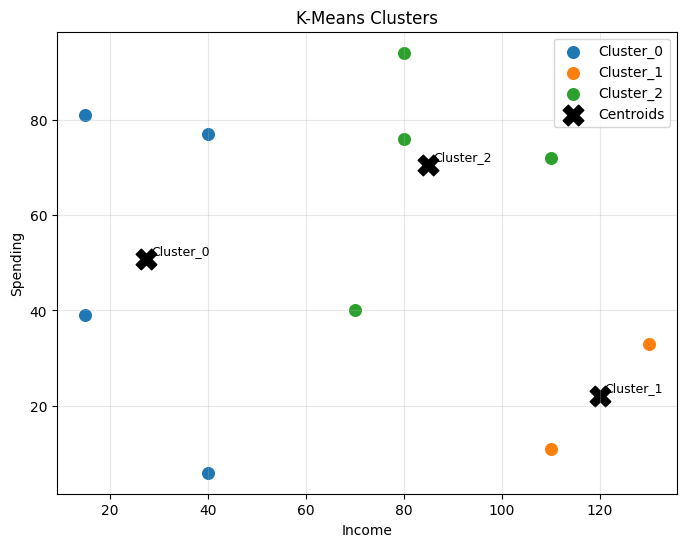

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Rebuild a clean clustering dataframe
df = pd.DataFrame({
    "Income": [15, 15, 40, 40, 70, 80, 80, 110, 110, 130],
    "Spending": [39, 81, 6, 77, 40, 76, 94, 11, 72, 33]
})

X = df[["Income", "Spending"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

print(kmeans.cluster_centers_)
# Cluster labels
df["Cluster"] = [f"Cluster_{i}" for i in kmeans.labels_]


dist_matrix = kmeans.transform(X)
for i in range(kmeans.n_clusters):
    df[f"dist_to_Cluster_{i}"] = dist_matrix[:, i]

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Income", "Spending"],
    index=[f"Cluster_{i}" for i in range(kmeans.n_clusters)]
)

print("--- Final Cluster Centers ---")
print(centroids)
print("\n--- Final Assignments ---")
print(df[["Income", "Spending", "Cluster"]])


silhouette_avg = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Coefficient: {silhouette_avg:.4f}")


plt.figure(figsize=(8, 6))

for cluster_name, group in df.groupby("Cluster"):
    plt.scatter(group["Income"], group["Spending"], s=70, label=cluster_name)

plt.scatter(
    centroids["Income"],
    centroids["Spending"],
    c="black",
    marker="X",
    s=220,
    label="Centroids"
)

for name, row in centroids.iterrows():
    plt.text(row["Income"] + 1, row["Spending"] + 1, name, fontsize=9)

plt.title("K-Means Clusters")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Calculate the Model Performance "Elbow Method"

WCSS values:
k=1: 23508.900
k=2: 11996.417
k=3: 7226.750
k=4: 3902.500
k=5: 2494.167
k=6: 1637.167
k=7: 924.500
k=8: 482.500
k=9: 162.000
k=10: 0.000


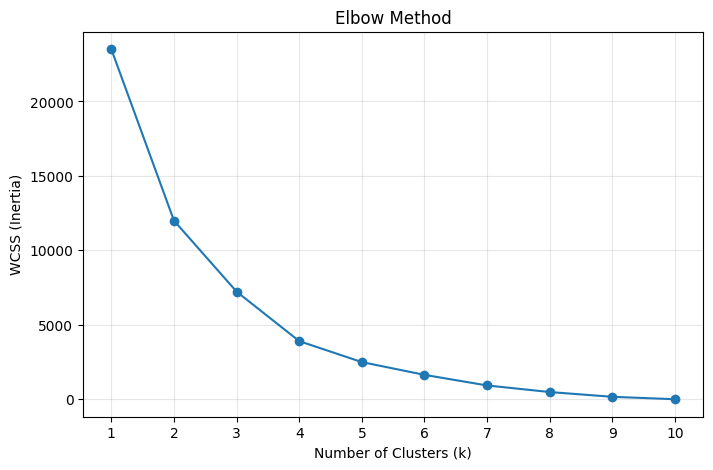


WCSS for k=3: 7226.750


In [8]:
# Elbow method (WCSS vs number of clusters)
X_elbow = df[["Income", "Spending"]].copy()

k_values = range(1, min(11, len(X_elbow) + 1))
wcss = []

for k_i in k_values:
    km = KMeans(n_clusters=k_i, random_state=42, n_init=10)
    km.fit(X_elbow)
    wcss.append(km.inertia_)

print("WCSS values:")
for k_i, val in zip(k_values, wcss):
    print(f"k={k_i}: {val:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

# WCSS for  chosen k (currently k=3)
kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_k.fit(X_elbow)
print(f"\nWCSS for k={k}: {kmeans_k.inertia_:.3f}")